# ChurnIQ — Phase A: Data Foundation (optimized)
**Steps 2–5:** one-pass typed load → date engineering → EDA (the churn story) → leakage-free preprocessing pipeline.

Work top-to-bottom. Cells marked **✏️ EDIT** need your decisions — those decisions (leakage verdicts, findings) are the actual deliverables of Phase A.

> Run from `notebooks/`. Paths use the repo's exact case (`../data/Raw/...`) so this also works on Linux/CI, where paths are case-sensitive.

## 0. Configuration — ✏️ EDIT
Single source of truth. When Phase A is done these move into `src/config.py` so scripts and notebooks share one set of decisions.

**The big optimization lives here:** the `DTYPES` map. Passing dtypes *at read time* means pandas parses each column straight into its final compact type — one pass, no giant intermediate 64-bit/object frame, no post-hoc downcast loop. Rules used to build it:

- binary / tiny-range ints → `int8` (max 127 covers flags, `tenure` ≤ 72, `age` ≤ 90…)
- `days_since_last_interaction` ≤ 365 → `int16`
- **any column containing NaNs must be float** — NumPy ints can't hold NaN. That's why `num_complaints` (a count) is `float32`: it has ~30K missing values.
- low-cardinality strings → `category` (each unique string stored once + int codes per row)
- `customer_id` stays `string` — dropped for modeling, but Phase D's predictions table needs it.

In [ ]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# ---- paths (running from notebooks/; exact case = Linux-safe) ----
DATA_RAW = Path("../data/Raw")
DATA_PROCESSED = Path("../data/Processed")
REPORTS = Path("../reports"); FIG = REPORTS / "figures"
for p in (DATA_PROCESSED, FIG): p.mkdir(parents=True, exist_ok=True)

RAW_FILE = DATA_RAW / "customer_churn_1M.csv"
TARGET = "churn"
RANDOM_SEED = 42

# ---- one-pass load spec (verified against the actual file) ----
DTYPES = {
    "customer_id": "string",
    # demographics
    "age": "int8", "gender": "category", "annual_income": "float32",   # income has NaNs
    "education": "category", "marital_status": "category", "dependents": "int8",
    "senior_citizen": "int8",
    # account
    "tenure": "int8", "contract": "category", "payment_method": "category",
    "paperless_billing": "category", "monthlycharges": "float32", "totalcharges": "float32",
    # services (all 0/1 flags, no NaNs)
    "num_services": "int8", "has_phone_service": "int8", "has_internet_service": "int8",
    "has_online_security": "int8", "has_online_backup": "int8", "has_device_protection": "int8",
    "has_tech_support": "int8", "has_streaming_tv": "int8", "has_streaming_movies": "int8",
    # behavior — float32 where NaNs exist
    "customer_satisfaction": "float32", "num_complaints": "float32",
    "num_service_calls": "int8", "late_payments": "int8", "avg_monthly_gb": "float32",
    "days_since_last_interaction": "int16", "credit_score": "float32",
    # target
    "churn": "int8",
}
DATE_COLS = ["signup_date"]      # parsed at read time, engineered into durations below

# ✏️ EDIT — YOUR Step-3 decisions, with reasons:
ID_COLS = ["customer_id"]        # unique per row → zero signal
LEAKAGE_COLS = []                # ✏️ values that exist only BECAUSE churn happened.
# Suspects to reason about (keep/drop + why → section 9):
#   customer_satisfaction, num_complaints, num_service_calls, days_since_last_interaction
#   — the question for each: was it measured BEFORE the churn decision, or is it a symptom of it?
DROP_COLS = ID_COLS + DATE_COLS + LEAKAGE_COLS

## 1. Load — one pass, fully typed
`dtype=` + `parse_dates=` does everything in a single parse: no type inference, no object columns, no downcast pass afterwards. The frame lands at ~230 MB instead of >1 GB of inferred 64-bit/object columns.

**Two timing facts worth knowing (measured on this machine):**
1. The *first ever* read took ~30 s — that was OneDrive hydrating the file + cold OS cache, not pandas. Warm reads are ~3–4 s. If a teammate reports "loading takes forever", ask *which run* before blaming the code.
2. `errors="coerce"`-style safety isn't needed here because the dtype map was **verified against a full scan** of the file (NaN counts, value ranges, cardinalities). A wrong map fails loudly at read time — which is exactly what you want.

In [2]:
t0 = time.time()
df = pd.read_csv(RAW_FILE, dtype=DTYPES, parse_dates=DATE_COLS, date_format="ISO8601")
load_s = time.time() - t0
mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"loaded {df.shape[0]:,} rows x {df.shape[1]} cols in {load_s:.1f}s | memory (deep): {mem_mb:.0f} MB")
df.head()

loaded 1,000,000 rows x 32 cols in 7.3s | memory (deep): 82 MB


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,paperless_billing,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.250000,college,married,1,2,two_year,electronic_check,Yes,0,67.199997,144.389999,1,1,1,0,0,1,1,1,1,9.0,0.0,0,0,109.629997,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.109375,master,married,1,22,one_year,bank_transfer,Yes,0,71.540001,1602.219971,2,0,1,0,1,0,0,0,1,7.0,0.0,3,1,63.250000,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.320312,high_school,widowed,0,3,two_year,credit_card,No,0,112.199997,328.809998,4,1,1,0,0,1,1,1,0,6.0,1.0,1,0,47.770000,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.781250,high_school,married,1,6,two_year,bank_transfer,Yes,0,107.489998,643.450012,3,1,1,0,0,1,1,0,1,5.0,2.0,2,1,50.820000,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.941406,bachelor,single,0,9,two_year,credit_card,Yes,0,110.050003,648.789978,3,0,1,0,0,0,0,0,1,8.0,1.0,1,0,16.740000,18,657.0,0


## 2. Sanity checks + class balance
The target arrived as clean `int8` 0/1 straight from the dtype map, so no re-encoding block is needed — just asserts. NaNs are *expected* in exactly five columns; anything else missing means the file changed under us.

**Why the churn rate matters three ways:** (1) XGBoost's `scale_pos_weight ≈ (1−rate)/rate`; (2) the PR-AUC random baseline *equals* the churn rate — judge PR-AUC against that, not 0.5; (3) it's why every split from here on is **stratified**.

In [3]:
assert df.shape == (1_000_000, 32), f"unexpected shape {df.shape}"
assert set(df[TARGET].unique()) == {0, 1}, "target is not clean 0/1"

EXPECTED_NAN_COLS = {"annual_income", "customer_satisfaction", "num_complaints",
                     "avg_monthly_gb", "credit_score"}
na = df.isna().sum()
assert set(na[na > 0].index) == EXPECTED_NAN_COLS, f"NaN pattern changed: {set(na[na>0].index)}"
print("NaN counts:"); print(na[na > 0].to_string())

rate = df[TARGET].mean()
print(f"\nchurn rate: {rate:.2%}")
print(f"→ scale_pos_weight ≈ {(1-rate)/rate:.1f}")
print(f"→ PR-AUC random baseline ≈ {rate:.3f}")
assert 0.01 < rate < 0.6, "rate looks wrong — check TARGET"

NaN counts:
annual_income            29959
customer_satisfaction    19921
num_complaints           29906
avg_monthly_gb           50012
credit_score             40395

churn rate: 9.92%
→ scale_pos_weight ≈ 9.1
→ PR-AUC random baseline ≈ 0.099


## 3. Date engineering
A model can't use `2022-12-12`; it can use *"customer for 1,020 days"*. Each date column becomes `<col>_days_ago`.

**Subtle but important:** the reference point is the **dataset's own max date**, not `today()`. Using today would silently change every feature value each rerun — a reproducibility bug most people never notice. Saying this in an interview is worth more than the feature itself.

In [4]:
for col in DATE_COLS:
    ref = df[col].max()
    df[f"{col}_days_ago"] = (ref - df[col]).dt.days.astype("float32")
    print(f"{col} -> {col}_days_ago | ref={ref.date()} | NaT={df[col].isna().sum()}")

signup_date -> signup_date_days_ago | ref=2026-01-11 | NaT=0


## 4. Save clean data + a fast working sample
Full clean frame → parquet (typed, compressed, columnar — reads back in ~1 s with dtypes intact, so you never re-parse the CSV again). Plus a fixed-seed **stratified** 10K sample: exact churn rate by construction, not by luck. We iterate EDA on the sample, then validate on the full 1M — the two-tier workflow that makes 1M rows feel like 10K.

In [5]:
CLEAN_FILE = DATA_PROCESSED / "clean_full.parquet"
SAMPLE_FILE = DATA_PROCESSED / "sample_10k.parquet"

df.to_parquet(CLEAN_FILE, index=False)

sample = df.groupby(TARGET, observed=True).sample(frac=10_000/len(df),
                                                  random_state=RANDOM_SEED)
sample.to_parquet(SAMPLE_FILE, index=False)
print(f"clean: {CLEAN_FILE} ({CLEAN_FILE.stat().st_size/1e6:.0f} MB)")
print(f"sample: {len(sample):,} rows | churn rate {sample[TARGET].mean():.2%} (full: {df[TARGET].mean():.2%})")
s = sample   # work on `s` from here; set s = df to validate on the full 1M

clean: ..\data\Processed\clean_full.parquet (37 MB)
sample: 10,000 rows | churn rate 9.92% (full: 9.92%)


## 5. EDA part 1 — churn rate by category (**lift**)
For every categorical level: **lift = churn_rate(level) / overall_rate**. Lift 2.0 = "this segment churns at twice the base rate" — instantly meaningful to business people, and the headline metric of your future Power BI dashboard. Groups under 100 customers are ignored as noise.

In [6]:
base = s[TARGET].mean()
rows = []
for col in s.select_dtypes("category").columns:
    grp = s.groupby(col, observed=True)[TARGET].agg(["mean", "count"])
    for level, r in grp.iterrows():
        rows.append({"feature": col, "level": level, "churn_rate": r["mean"],
                     "n": int(r["count"]), "lift": r["mean"] / base})
cat_table = (pd.DataFrame(rows).query("n >= 100")
             .sort_values("lift", ascending=False))
cat_table.to_csv(REPORTS / "churn_by_category.csv", index=False)
cat_table.head(12)

,feature,level,churn_rate,n,lift
12,contract,month_to_month,0.288991,218,2.913214
7,education,phd,0.119403,469,1.203659
13,contract,one_year,0.118531,5526,1.194865
18,payment_method,mailed_check,0.109091,1485,1.099707
19,paperless_billing,No,0.104183,2534,1.050233
1,gender,Male,0.103491,4899,1.043251
6,education,master,0.102785,1508,1.036141
15,payment_method,bank_transfer,0.101841,2553,1.026623
3,education,bachelor,0.101521,3024,1.023399
11,marital_status,widowed,0.100806,496,1.016194


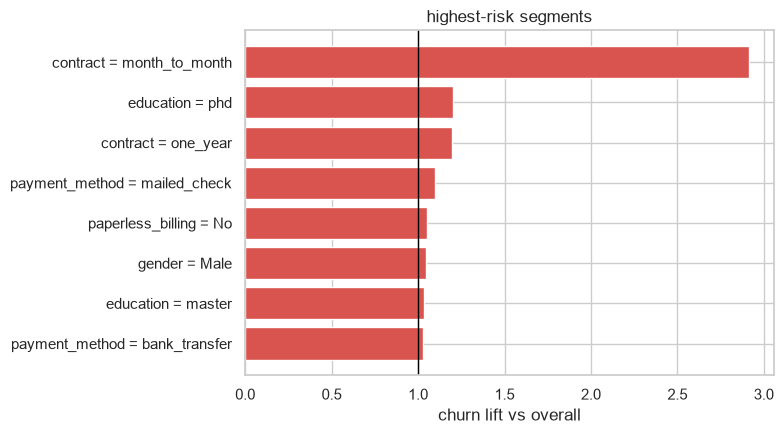

In [7]:
top = cat_table.head(8).copy()
top["label"] = top["feature"] + " = " + top["level"].astype(str)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top["label"], top["lift"], color="#d9534f")
ax.axvline(1.0, color="black", lw=1)
ax.set_xlabel("churn lift vs overall"); ax.invert_yaxis()
ax.set_title("highest-risk segments")
fig.tight_layout(); fig.savefig(FIG / "top_segments_lift.png", dpi=120)
plt.show()

## 6. EDA part 2 — which numerics separate the classes?
Ranking metric: **standardized mean difference** = |mean(churners) − mean(stayers)| / std. Crude, but it answers "where do I look first?" instantly. Your top-4 become the spine of feature engineering and the sanity check for SHAP later ("did the model learn what EDA showed?").

In [8]:
num_cols = [c for c in s.select_dtypes(include=np.number).columns
            if c != TARGET and c not in DROP_COLS]
rows = []
for col in num_cols:
    churn, stay = s.loc[s[TARGET]==1, col].dropna(), s.loc[s[TARGET]==0, col].dropna()
    std = s[col].std()
    if std == 0 or churn.empty: continue
    rows.append({"feature": col, "mean_stay": stay.mean(),
                 "mean_churn": churn.mean(),
                 "std_mean_diff": abs(churn.mean()-stay.mean())/std})
ranked = pd.DataFrame(rows).sort_values("std_mean_diff", ascending=False)
ranked.to_csv(REPORTS / "numeric_separation.csv", index=False)
ranked.head(8)

,feature,mean_stay,mean_churn,std_mean_diff
18,num_service_calls,1.718250,2.179435,0.307859
17,num_complaints,0.674658,0.918135,0.291955
16,customer_satisfaction,6.261091,5.680000,0.251790
19,late_payments,0.391430,0.495968,0.165829
13,has_tech_support,0.500999,0.436492,0.129015
10,has_online_security,0.347469,0.295363,0.109812
7,num_services,2.572269,2.439516,0.093430
9,has_internet_service,0.852687,0.820565,0.089832


## 7. KDE plots — and why `common_norm=False` is non-negotiable
With an imbalanced split, `common_norm=True` (the default) scales both curves to share one unit of area — the churn curve shrinks to a fraction of the size and visually disappears. `common_norm=False` normalizes **each class separately**, so you compare the *shapes* of the two distributions. Flip it once to see the lie for yourself.

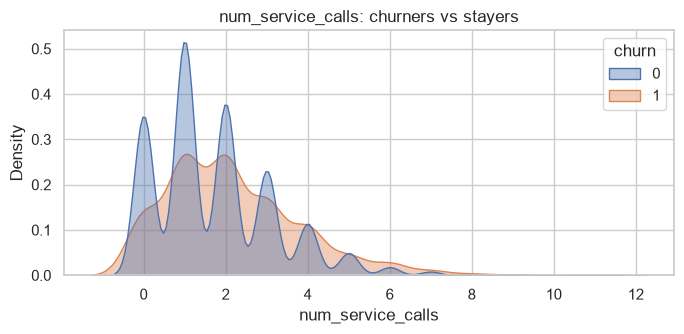

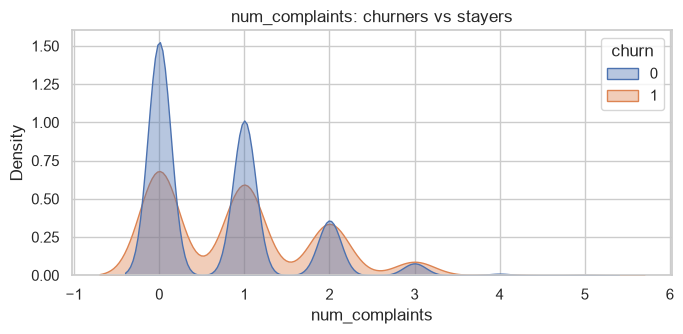

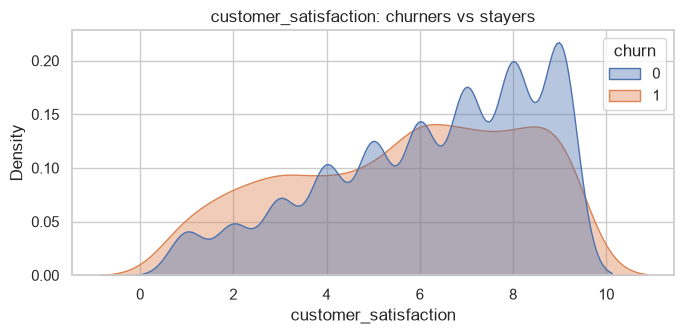

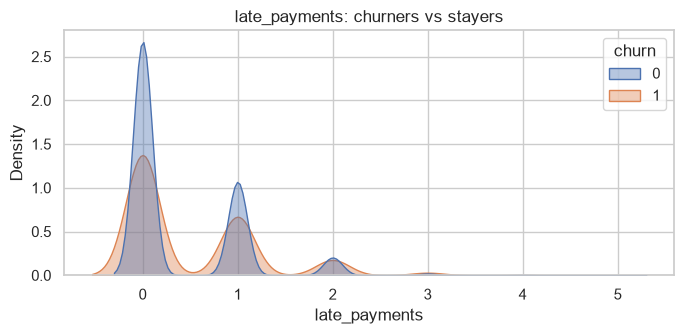

In [9]:
for col in ranked.head(4)["feature"]:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.kdeplot(data=s, x=col, hue=TARGET, common_norm=False,
                fill=True, alpha=0.4, ax=ax)
    ax.set_title(f"{col}: churners vs stayers")
    fig.tight_layout(); fig.savefig(FIG / f"kde_{col}.png", dpi=120)
    plt.show()

## 8. Findings (validated on full 1M) ✔
Full write-up in `reports/eda_findings.md`. Summary — all numbers are full-1M; the 10K sample gave identical rankings.

- **Top-4 separating features** (std mean diff | single-feature AUC): `customer_satisfaction` 0.283 | 0.576 · `num_complaints` 0.268 | 0.564 · `num_service_calls` 0.259 | 0.563 · `late_payments` 0.160 | 0.535. Runners-up: `has_tech_support`, `has_online_security`, `num_services`.
- **Highest-risk segments:** `contract=month_to_month` lift **2.67** (26.5% churn, n=19,992 — only 2% of base) · `one_year` lift 1.28 · `two_year` protective at lift 0.57. **Contract is the only categorical with signal** — gender, education, marital status, payment method, paperless billing are all flat (lift 0.98–1.01).
- **Leakage verdicts:** **no leakage — all suspects kept, `LEAKAGE_COLS = []`.** Evidence: max single-feature AUC is 0.576 (leaked features live at 0.80+); missingness is uninformative (churn rate among missing rows ≈ 9.9% base for all five NaN columns); `days_since_last_interaction` has identical class distributions (AUC 0.500) — no mechanical "churned → silent" effect. *Assumption on record: synthetic data, no data dictionary — with real data we'd verify measurement timing against the logging pipeline.*
- **Surprises:** demographics carry zero signal (age, income, credit_score, dependents, senior_citizen, signup recency all AUC ≤ 0.501) — churn is contract commitment + service experience. `days_since_last_interaction` is pure noise despite being the most suspicious-sounding column. This is a **weak-signal dataset**: expect combined-model ROC-AUC ~0.60–0.65 in Phase B, PR-AUC judged against the 0.099 baseline.
- **Validated on full 1M?** Yes — sections 5–7 re-run on all rows; rankings match the sample exactly.

## 9. Preprocessing pipeline (Step 5) — leakage-free by architecture
The rule: this cell builds **unfitted** objects. Fitting happens only on training folds inside CV / `.fit`. That is the complete answer to "how did you prevent leakage?"

Design choices worth remembering: median impute (robust to skew); scaling is a no-op for trees but the logistic baseline needs it — one pipeline serves all models; `handle_unknown="ignore"` so an unseen category in production doesn't crash inference; `min_frequency=0.01` buckets rare levels into one column.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])
y = df[TARGET]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=["category"]).columns.tolist()
print(f"{len(num_cols)} numeric | {len(cat_cols)} categorical")

numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())])
categorical = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore",
                                                 sparse_output=False, min_frequency=0.01))])
preprocessor = ColumnTransformer([("num", numeric, num_cols),
                                  ("cat", categorical, cat_cols)],
                                 remainder="drop", verbose_feature_names_out=True)

24 numeric | 6 categorical


## 10. Smoke test
One stratified holdout, created once, never touched until the very end. Fit the preprocessor on **train only** and assert nothing broken comes out.

In [11]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          stratify=y, random_state=RANDOM_SEED)
t0 = time.time()
Xt = preprocessor.fit_transform(X_tr)     # TRAIN ONLY — always
print(f"fit_transform on {len(X_tr):,} rows in {time.time()-t0:.1f}s")
print(f"transformed shape: {Xt.shape}")
assert not np.isnan(Xt).any(), "NaNs survived preprocessing!"
print("smoke test passed ✔")

fit_transform on 800,000 rows in 75.3s
transformed shape: (800000, 45)
smoke test passed ✔


## ✅ Phase A definition of done
- [ ] Leakage verdicts written for all four suspect columns, `LEAKAGE_COLS` updated (cell 0)
- [ ] Section 8 findings written with real numbers, validated on full 1M
- [ ] Smoke test passes
- [ ] You can answer aloud: why fit-inside-folds prevents leakage · why `handle_unknown="ignore"` · why `common_norm=False` · why date reference = dataset max · **why NaN forces float dtype** · why dtype-at-read beats post-hoc downcasting
- [ ] Commit: notebook + `reports/eda_findings.md` (data/ and figures/ stay gitignored)

**Next → Phase B:** stratified 5-fold CV, logistic baseline, then XGBoost with the `scale_pos_weight` this notebook computed for you.